# Correlación de Pearson

**Integrantes:**
- Israel Juárez
- Tiffany Martínez

# Importaciones de bibliotecas

In [11]:
import os
import re
import cv2
import dlib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd  
from scipy.stats import pearsonr
import seaborn as sns 

#### Función `ordenar_numerico`

Esta función se encarga de ordenar nombres de archivos de forma numérica en lugar de alfabética, lo cual es útil para nombres que incluyen secuencias de números, como "imagen1", "imagen2", etc.

1. **Expresión Regular**: Usa una expresión regular para identificar secuencias de dígitos en el nombre del archivo.
2. **División de la Cadena**: Divide el nombre del archivo en partes numéricas y alfabéticas.
3. **Conversión a Entero**: Convierte las partes numéricas en enteros parav un ordenamiento adecuado.


In [12]:
def ordenar_numerico(valor):
    numeros = re.compile(r'(\d+)')
    partes = numeros.split(valor)
    partes[1::2] = list(map(int, partes[1::2]))
    return partes


#### Función `leer_datos(ruta_base)`

Esta función lee los datos de un directorio base específico que contiene subdirectorios con archivos de texto y secuencias de imágenes. Su objetivo es cargar los valores de emoción asociados a las imágenes y organizar estos datos para su posterior análisis.

1. **Recorrer Directorios y Filtrar Archivos**: Usa `os.walk` para recorrer todos los subdirectorios en `ruta_base`, excluyendo archivos y directorios ocultos.
2. **Ordenar Archivos**: Ordena los archivos y directorios numéricamente mediante `ordenar_numerico`.
3. **Leer Archivos de Texto**: Para cada archivo de texto, intenta leer el valor de emoción y convertirlo a entero.
4. **Buscar Imágenes Asociadas**: Encuentra la última imagen de la secuencia en el directorio de imágenes relacionado.
5. **Guardar Resultados**: Para cada valor de emoción y su imagen asociada, se agrega una tupla con su ruta y valor.


In [13]:
def leer_datos(ruta_base):
    datos = []
    
    for dir_act, subdirs, archivos in os.walk(ruta_base):
        subdirs[:] = [d for d in subdirs if not d.startswith('.')]
        archivos = [f for f in archivos if not f.startswith('.')]
        subdirs.sort(key=ordenar_numerico)
        archivos.sort(key=ordenar_numerico)
        
        for arch in archivos:
            if arch.endswith('.txt'):
                ruta_arch = os.path.join(dir_act, arch)
                try:
                    with open(ruta_arch, 'r') as f:
                        valor = f.read().strip()
                    try:
                        valor = int(float(valor))
                    except ValueError as e:
                        print(f"Error al convertir el número en {ruta_arch}: {e}")
                        continue

                    dir_rel = os.path.relpath(dir_act, ruta_base)
                    dir_img = os.path.join('cohn-kanade-images', dir_rel)
                    imgs = [f for f in os.listdir(dir_img) if f.endswith('.png')]
                    imgs.sort(key=ordenar_numerico)
                    
                    if imgs:
                        ruta_img_expresion = os.path.join(dir_img, imgs[-1])  
                        datos.append((ruta_img_expresion, valor))
                    else:
                        print(f"No se encontraron imágenes en {dir_img}")
                except Exception as e:
                    print(f"Error leyendo {ruta_arch}: {e}")
    return datos


#### Configuración de Detector y Predictor de Landmarks de Dlib

Antes de la función `extraer_puntos`, se cargan dos componentes esenciales de `dlib`:

1. **Detector de Rostros**:
   - `det = dlib.get_frontal_face_detector()`: Este es el detector de rostros preentrenado de `dlib`, que identifica el área del rostro en una imagen. Este detector está optimizado para detectar rostros frontales y produce una lista de rectángulos delimitadores, cada uno correspondiente a un rostro detectado en la imagen.
   
2. **Predictor de Landmarks**:
   - `pred = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")`: El predictor de landmarks usa un modelo preentrenado (archivo `shape_predictor_68_face_landmarks.dat`) que localiza 68 puntos faciales específicos en el área del rostro detectado. Este predictor es crucial para obtener los landmarks en coordenadas `(x, y)` de las características faciales (por ejemplo, cejas, ojos, nariz y boca).


In [14]:
det = dlib.get_frontal_face_detector()
pred = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

#### Función `extraer_puntos(ruta_imagen)`

Esta función utiliza `dlib` y `cv2` para detectar un rostro en una imagen y extraer un conjunto de 68 puntos faciales (landmarks) específicos que describen características faciales clave, como el contorno de la cara, cejas, ojos, nariz y boca. Estos puntos son útiles en aplicaciones de reconocimiento facial y análisis de expresiones.

1. **Carga de la Imagen**:
   - `cv2.imread(ruta_imagen)`: Carga la imagen especificada en `ruta_imagen`. Si la imagen no se puede cargar (por ejemplo, si la ruta es incorrecta o el archivo está dañado), la función imprime un mensaje de error y retorna `None`, lo que evita que el código continúe con una imagen inválida.

2. **Detección de Rostros**:
   - `det(imagen, 1)`: Usa el detector de rostros de `dlib` para detectar caras en la imagen cargada. Este detector retorna una lista de rostros detectados en la imagen. Cada rostro está representado como un rectángulo delimitador que indica la ubicación del rostro en la imagen.
   - Si no se detecta ningún rostro (`len(rostros) == 0`), la función imprime un mensaje de aviso y retorna `None`, indicando que no se encontraron rostros para analizar en esa imagen.

3. **Extracción de Puntos Faciales (Landmarks)**:
   - Para cada rostro detectado (en este caso, se espera solo uno), la función utiliza el predictor de `dlib`, `shape_predictor`, cargado previamente con un modelo de puntos faciales. Este predictor está diseñado para identificar 68 puntos específicos en el rostro.
   - `pred(imagen, rostro)`: Extrae los 68 puntos faciales del área delimitada por `rostro`. Los puntos obtenidos son coordenadas `(x, y)` que representan las ubicaciones de las características faciales clave.
   - `lista_puntos = [(puntos.part(n).x, puntos.part(n).y) for n in range(68)]`: Convierte los puntos extraídos en una lista de tuplas de coordenadas `(x, y)`, donde cada tupla corresponde a uno de los 68 landmarks.

4. **Retorno de Resultados**:
   - La función retorna `lista_puntos`, una lista de tuplas de coordenadas que representan los 68 puntos faciales en el rostro detectado.
   - Si por alguna razón no se logra extraer puntos faciales (por ejemplo, si `pred` falla), la función retorna `None`, lo que ayuda a evitar errores en etapas posteriores del análisis.


In [15]:
def extraer_puntos(ruta_imagen):
    imagen = cv2.imread(ruta_imagen)
    if imagen is None:
        print(f"No se pudo cargar la imagen {ruta_imagen}")
        return None

    rostros = det(imagen, 1)
    if len(rostros) == 0:
        print(f"No se detectaron rostros en {ruta_imagen}")
        return None

    for rostro in rostros:
        puntos = pred(imagen, rostro)
        lista_puntos = [(puntos.part(n).x, puntos.part(n).y) for n in range(68)]
        return lista_puntos
    return None

#### Función `centrar_pts(pts)`

Esta función centra los puntos faciales en torno a un punto central entre los ojos, normalizando la posición del rostro en las imágenes.

In [16]:
def centrar_pts(pts):
    ojo_izq = np.mean(pts[36:42], axis=0)
    ojo_der = np.mean(pts[42:48], axis=0)
    punto_central = (ojo_izq + ojo_der) / 2
    pts_centrados = pts - punto_central
    return pts_centrados

#### Función `extraer_landmarks(datos)`

Esta función procesa un conjunto de datos de imágenes y emociones, extrayendo puntos faciales centrados (landmarks) de cada rostro y asociándolos con su emoción correspondiente.

1. **Inicialización de Listas**: Se crean listas para almacenar los puntos faciales (`lista_pts`), emociones (`lista_emo`), y rutas de imágenes (`lista_ruta_img_expresion`).

2. **Recorrer Datos**: La función itera sobre cada imagen en `datos`, donde cada elemento incluye una ruta de imagen y un valor de emoción. Si el formato es incorrecto, omite el elemento.

3. **Extracción y Centrado de Puntos Faciales**: Llama a `extraer_puntos` para obtener 68 puntos faciales de cada rostro. Luego, estos puntos son centrados alrededor del punto medio de los ojos con `centrar_pts`.

4. **Almacenamiento**: Agrega los puntos faciales centrados, la emoción, y la ruta de imagen a las listas correspondientes.

5. **Conversión y Retorno**: Convierte las listas de puntos y emociones en arrays de `numpy`:
   - `X`: array de puntos faciales con forma `(n_samples, 68, 2)`.
   - `y`: array de emociones.
   - La función retorna `X`, `y`, y las rutas de imágenes procesadas.


In [17]:
def extraer_landmarks(datos):
    lista_pts = []
    lista_emo = []
    lista_ruta_img_expresion = []
    
    for item in datos:
        if len(item) != 2:
            print(f"Elemento ignorado: formato inesperado {item}")
            continue

        ruta_img_expresion, emo = item
        pts_expresion = extraer_puntos(ruta_img_expresion)

        if pts_expresion is not None:
            pts_expresion = np.array(pts_expresion)
            pts_expresion_centrados = centrar_pts(pts_expresion)
            lista_pts.append(pts_expresion_centrados) 
            lista_emo.append(emo)
            lista_ruta_img_expresion.append(ruta_img_expresion)
        else:
            print(f"No se pudieron extraer puntos de {ruta_img_expresion}")

    if not lista_pts:
        print("No se extrajeron puntos faciales.")
        return None, None, None

    X = np.array(lista_pts)  # X(n_samples, 68, 2)
    y = np.array(lista_emo)
    return X, y, lista_ruta_img_expresion



### Ejecución de Lectura y Extracción

- **Ruta Base**: especifica el directorio de datos.
- **Lectura**: `datos = leer_datos(ruta_base)` obtiene rutas de imágenes y emociones.
- **Extracción**: `X, y, paths_expresion = extraer_landmarks(datos)` devuelve puntos faciales (`X`), emociones (`y`), y rutas de imágenes.


In [18]:
ruta_base = 'Emotion'
datos = leer_datos(ruta_base)
# Extraer los landmarks y las emociones
X, y, paths_expresion = extraer_landmarks(datos)

### Cálculo de la Magnitud de Landmarks y Matriz de Correlación de Pearson
Este bloque de código calcula y visualiza la **matriz de correlación de Pearson** para los puntos faciales (landmarks) en un conjunto de datos de rostros. La finalidad es analizar cómo se relacionan las posiciones de estos puntos entre sí.

1. **Cálculo de la Magnitud de los Landmarks**: 
   - Se calcula una magnitud única para cada punto facial, representando su posición de manera simplificada.

2. **Asignación de Nombres a los Landmarks**:
   - Cada punto recibe un nombre específico según su posición en el rostro (como "Contorno" o "Nariz").

3. **Creación del DataFrame**:
   - Los datos se organizan en un `DataFrame` para facilitar el análisis.

4. **Cálculo y Visualización de la Matriz de Correlación**:
   - Se calcula la correlación entre los puntos y se visualiza en un mapa de calor, permitiendo identificar patrones de relación entre zonas faciales.

Este proceso ayuda a entender mejor las relaciones y patrones de movimiento entre diferentes zonas del rostro, siendo útil para aplicaciones de reconocimiento facial y análisis de expresiones.

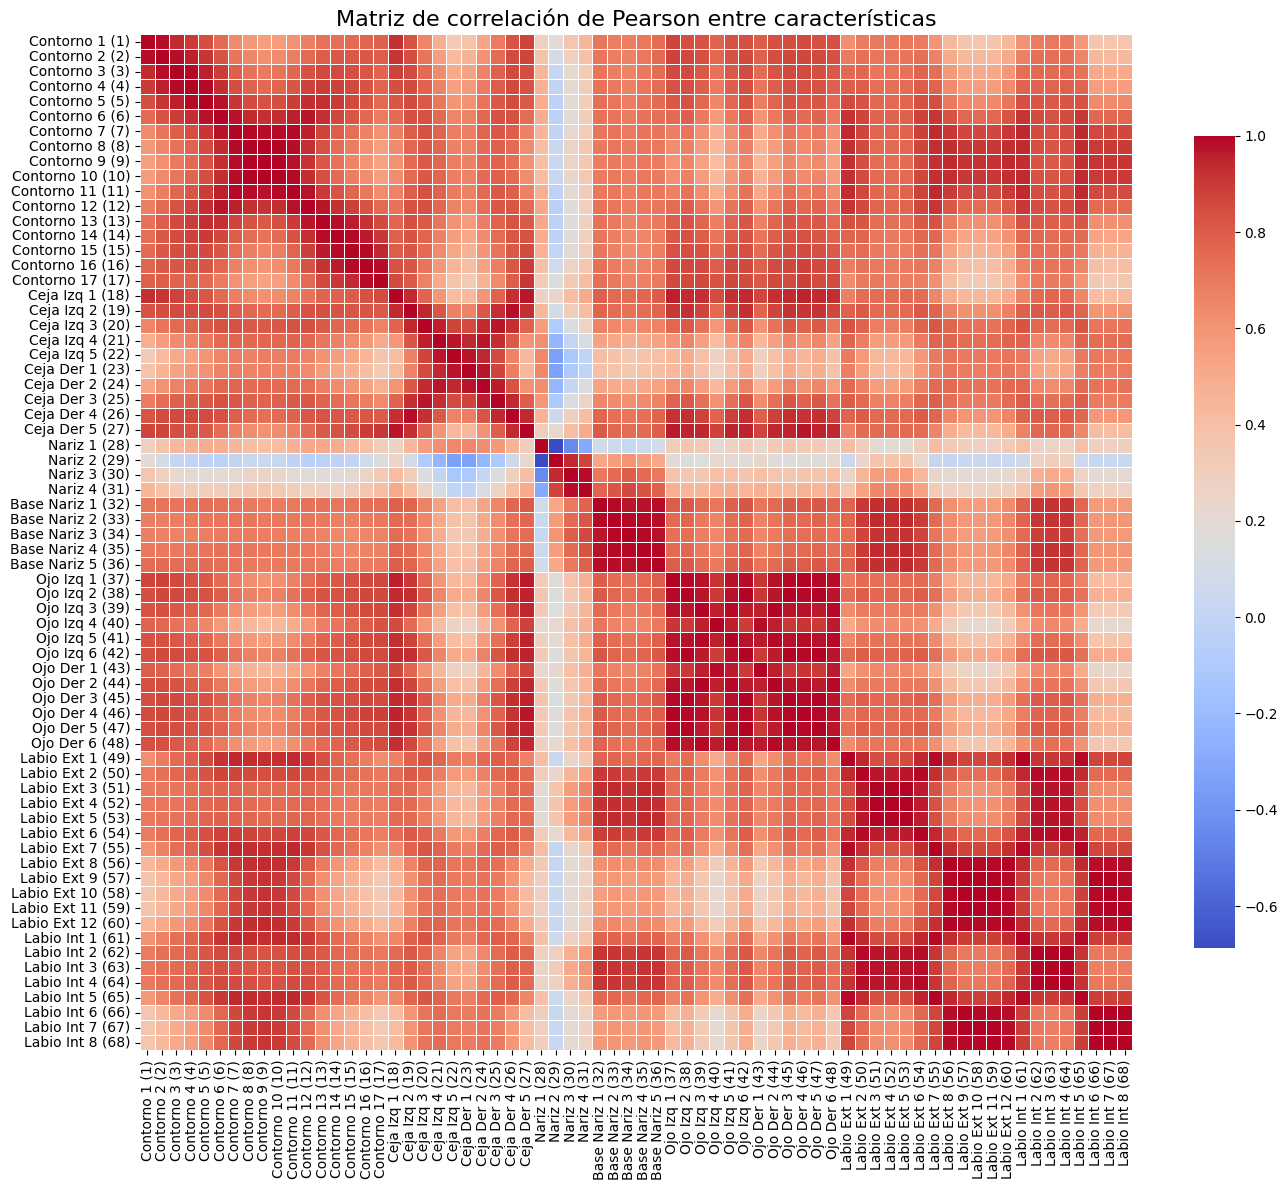

In [19]:
X_magnitudes = np.linalg.norm(X, axis=2) 
X_magnitudes_68 = X_magnitudes[:, :68]  

feature_names = [
    "Contorno 1 (1)", "Contorno 2 (2)", "Contorno 3 (3)", "Contorno 4 (4)", "Contorno 5 (5)", 
    "Contorno 6 (6)", "Contorno 7 (7)", "Contorno 8 (8)", "Contorno 9 (9)", "Contorno 10 (10)",
    "Contorno 11 (11)", "Contorno 12 (12)", "Contorno 13 (13)", "Contorno 14 (14)", "Contorno 15 (15)", 
    "Contorno 16 (16)", "Contorno 17 (17)", 

    "Ceja Izq 1 (18)", "Ceja Izq 2 (19)", "Ceja Izq 3 (20)", "Ceja Izq 4 (21)", "Ceja Izq 5 (22)",  

    "Ceja Der 1 (23)", "Ceja Der 2 (24)", "Ceja Der 3 (25)", "Ceja Der 4 (26)", "Ceja Der 5 (27)",  

    "Nariz 1 (28)", "Nariz 2 (29)", "Nariz 3 (30)", "Nariz 4 (31)", 

    "Base Nariz 1 (32)", "Base Nariz 2 (33)", "Base Nariz 3 (34)", "Base Nariz 4 (35)", "Base Nariz 5 (36)",  

    "Ojo Izq 1 (37)", "Ojo Izq 2 (38)", "Ojo Izq 3 (39)", "Ojo Izq 4 (40)", "Ojo Izq 5 (41)", "Ojo Izq 6 (42)",  

    "Ojo Der 1 (43)", "Ojo Der 2 (44)", "Ojo Der 3 (45)", "Ojo Der 4 (46)", "Ojo Der 5 (47)", "Ojo Der 6 (48)",  

    "Labio Ext 1 (49)", "Labio Ext 2 (50)", "Labio Ext 3 (51)", "Labio Ext 4 (52)", "Labio Ext 5 (53)", "Labio Ext 6 (54)", 
    "Labio Ext 7 (55)", "Labio Ext 8 (56)", "Labio Ext 9 (57)", "Labio Ext 10 (58)", "Labio Ext 11 (59)", "Labio Ext 12 (60)",  

    "Labio Int 1 (61)", "Labio Int 2 (62)", "Labio Int 3 (63)", "Labio Int 4 (64)", "Labio Int 5 (65)", "Labio Int 6 (66)", 
    "Labio Int 7 (67)", "Labio Int 8 (68)" 
]


df_features = pd.DataFrame(X_magnitudes_68, columns=feature_names)

#Calcular la matriz de correlación de Pearson
corr_matrix = df_features.corr(method='pearson')

#Graficar la matriz de correlación
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, 
            annot=False,       
            cmap='coolwarm', 
            linewidths=0.5, 
            fmt=".2f", 
            xticklabels=feature_names, 
            yticklabels=feature_names,
            cbar_kws={"shrink": .8})
plt.title('Matriz de correlación de Pearson entre características', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Análisis de la Matriz de Correlación de Pearson

La matriz de correlación de Pearson ofrece una visión clara de las relaciones y patrones de movimiento entre los distintos puntos faciales (landmarks) en el rostro. Las zonas faciales muestran correlaciones internas fuertes, lo cual es consistente con la anatomía y los movimientos típicos de cada área.

- **Contorno Facial (Puntos 1-17)**: Los puntos en el contorno de la cara están altamente correlacionados entre sí, lo cual es lógico ya que juntos definen la estructura externa y fija del rostro. Esto sugiere que estos puntos se mueven de forma coordinada, manteniendo la forma general del contorno facial.

- **Cejas y Ojos (Puntos 18-27 y 37-48)**: Las cejas y los ojos presentan correlaciones altas dentro de sus grupos respectivos, lo que indica que se mueven como conjuntos independientes. Sin embargo, estas zonas muestran una menor correlación con otras áreas del rostro, sugiriendo que su movimiento es más autónomo, posiblemente debido a su papel en gestos específicos como el fruncir o levantar las cejas, que no afectan significativamente otras partes de la cara.

- **Nariz (Puntos 28-36)**: La región de la nariz mantiene una alta correlación interna debido a su posición fija y estructura rígida. Esto refleja la naturaleza estable de la nariz en comparación con otras áreas que están más involucradas en expresiones dinámicas.

- **Labios (Puntos 49-68)**: Los puntos alrededor de los labios están altamente correlacionados entre sí, indicando movimientos coordinados durante expresiones faciales como sonreír o fruncir el ceño. Esto es consistente con el hecho de que los labios tienden a moverse en conjunto durante gestos y emociones.

- **Interacciones Entre Zonas**: Las correlaciones más bajas entre zonas distantes, como ojos y boca, sugieren movimientos independientes de estas áreas. Los puntos de los ojos y las cejas, por ejemplo, muestran correlaciones entre sí debido a expresiones que pueden involucrar el movimiento conjunto de ambas zonas (como levantar las cejas), mientras que los puntos de la boca y la nariz muestran poca correlación con los ojos y las cejas, reflejando la independencia en sus movimientos.


In [1]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# Función para calcular distancias entre landmarks
def calcular_distancias(landmarks):
    distancias = []
    for i in range(len(landmarks)):
        for j in range(i + 1, len(landmarks)):
            distancias.append(np.linalg.norm(landmarks[i] - landmarks[j]))
    return distancias

# Calcular distancias para cada imagen
distancias = [calcular_distancias(pts) for pts in X]

# Convertir a un DataFrame para facilidad de manejo
distancias_df = pd.DataFrame(distancias)
distancias_df['emotions'] = y  # Añadir las emociones como columna

# Correlación de Spearman
correlaciones = []
for col in distancias_df.columns[:-1]:  # Excluir la columna de emociones
    corr, _ = spearmanr(distancias_df[col], distancias_df['emotions'])
    correlaciones.append((col, corr))

# Mostrar las correlaciones más altas y bajas
correlaciones = sorted(correlaciones, key=lambda x: x[1], reverse=True)
print("Correlaciones de Spearman (ordenadas):")
for col, corr in correlaciones[:5]:  # Top 5 correlaciones más altas
    print(f"Columna {col}: {corr}")


NameError: name 'X' is not defined